<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/tree_based_models/model_experiment_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & MLflow

In [3]:
!pip install -q lightgbm mlflow dagshub

from google.colab import userdata
import dagshub

token = userdata.get("DAGSHUB_TOKEN")
assert token, "DAGSHUB_TOKEN secret missing or notebook access not enabled"

dagshub.auth.add_app_token(token)
dagshub.init(repo_owner="adzid23", repo_name="Freeuni_ML_Walmart_Sales_Forecasting", mlflow=True)

import mlflow
mlflow.set_experiment("LightGBM_Training")

Accessing as adzid23

Initialized MLflow to track repo "adzid23/Freeuni_ML_Walmart_Sales_Forecasting"

Repository adzid23/Freeuni_ML_Walmart_Sales_Forecasting initialized!

2026/07/12 10:47:58 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/ccdf12f3ff7f4ab3a50ad52baeaaaa7d', creation_time=1783853278326, effective_trace_archival_retention=None, experiment_id='7', last_update_time=1783853278326, lifecycle_stage='active', name='LightGBM_Training', tags={}, trace_location=None, workspace='default'>

## 2. Data

In [5]:
import os, zipfile
import numpy as np, pandas as pd

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting -q

os.makedirs('walmart_data', exist_ok=True)
with zipfile.ZipFile('walmart-recruiting-store-sales-forecasting.zip') as z:
    z.extractall('walmart_data')
for f in os.listdir('walmart_data'):
    if f.endswith('.zip'):
        with zipfile.ZipFile(f'walmart_data/{f}') as z:
            z.extractall('walmart_data')

train  = pd.read_csv('walmart_data/train.csv',    parse_dates=['Date'])
test   = pd.read_csv('walmart_data/test.csv',     parse_dates=['Date'])
stores = pd.read_csv('walmart_data/stores.csv')
feats  = pd.read_csv('walmart_data/features.csv', parse_dates=['Date'])

print(train.shape, test.shape, stores.shape, feats.shape)
print('Feats:', feats['Date'].min().date(), '→', feats['Date'].max().date())

(421570, 5) (115064, 4) (45, 3) (8190, 12)
Feats: 2010-02-05 → 2013-07-26


## 3. Exogenous Features

In [6]:
md = [f'MarkDown{i}' for i in range(1, 6)]
feats[md] = feats[md].fillna(0.0)
feats['Total_MarkDown'] = feats[md].sum(axis=1)
feats['Num_MarkDowns']  = (feats[md] > 0).sum(axis=1)
feats['Max_MarkDown']   = feats[md].max(axis=1)

feats = feats.sort_values(['Store', 'Date'])
feats[['CPI', 'Unemployment']] = feats.groupby('Store')[['CPI', 'Unemployment']].ffill()

exog = feats.drop(columns=['IsHoliday'] + md)
print(exog.isna().sum().sum(), 'NaNs left')
exog.head(3)

0 NaNs left


,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,Total_MarkDown,Num_MarkDowns,Max_MarkDown
0,1,2010-02-05,42.31,2.572,211.096358,8.106,0.0,0,0.0
1,1,2010-02-12,38.51,2.548,211.242170,8.106,0.0,0,0.0
2,1,2010-02-19,39.93,2.514,211.289143,8.106,0.0,0,0.0


## 4. Holiday Calendar

In [7]:
HOLIDAYS = {k: pd.to_datetime(v) for k, v in {
    'superbowl':    ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
    'laborday':     ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
    'thanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
    'christmas':    ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'],
}.items()}
ALL_HOLIDAYS = pd.DatetimeIndex(sorted(set().union(*[set(v) for v in HOLIDAYS.values()])))

# quick check: signed weeks from each date to nearest Christmas
demo = pd.date_range('2012-12-07', '2013-01-11', freq='W-FRI')
diffs = (demo.values[:, None] - HOLIDAYS['christmas'].values[None, :]) / np.timedelta64(1, 'W')
nearest = diffs[np.arange(len(demo)), np.abs(diffs).argmin(axis=1)]
print(pd.Series(nearest.round(1), index=demo.date))

2012-12-07   -3.0
2012-12-14   -2.0
2012-12-21   -1.0
2012-12-28    0.0
2013-01-04    1.0
2013-01-11    2.0
dtype: float64


## 5. Panel Builder - one leak-free featurizer

In [8]:
HORIZON, LAGS, ROLLS = 13, [13, 26, 39, 52], [13, 26]

def build_panel(history, target=None):
    hist = history[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
    hist['is_target'] = False
    if target is not None:
        tgt = target[['Store', 'Dept', 'Date']].copy()
        tgt['Weekly_Sales'] = np.nan
        tgt['is_target'] = True
        cutoff = tgt['Date'].min()
        df = pd.concat([hist, tgt], ignore_index=True)
    else:
        cutoff = hist['Date'].max() + pd.Timedelta(weeks=1)
        df = hist

    df = df.set_index(['Store', 'Dept', 'Date']).sort_index()

    # full weekly grid per series
    bounds = df.reset_index().groupby(['Store', 'Dept'])['Date'].agg(['min', 'max'])
    idx = pd.MultiIndex.from_tuples(
        [(s, d, w) for (s, d), r in bounds.iterrows()
                   for w in pd.date_range(r['min'], r['max'], freq='W-FRI')],
        names=['Store', 'Dept', 'Date'])
    df = df.reindex(idx)
    df['is_target'] = df['is_target'].astype(object).fillna(False).astype(bool)
    df['was_observed'] = df['Weekly_Sales'].notna() & ~df['is_target']

    dates = df.index.get_level_values('Date')
    gap = df['Weekly_Sales'].isna() & (dates < cutoff) & ~df['is_target']
    df.loc[gap, 'Weekly_Sales'] = 0.0

    # lags & rolling stats on a masked copy (gap zeros -> NaN, section leaders' trick)
    masked = df['Weekly_Sales'].where(~gap)
    g = masked.groupby(level=['Store', 'Dept'])
    for k in LAGS:
        df[f'lag_{k}'] = g.shift(k)
    base = g.shift(HORIZON)
    gb = base.groupby(level=['Store', 'Dept'])
    for w in ROLLS:
        df[f'rmean_{w}'] = gb.rolling(w, min_periods=4).mean().droplevel([0, 1])
        df[f'rstd_{w}']  = gb.rolling(w, min_periods=4).std().droplevel([0, 1])

    # per-series aggregates from pre-cutoff observed data only
    agg = (masked[dates < cutoff]
           .groupby(level=['Store', 'Dept']).agg(['mean', 'std', 'median']))
    agg.columns = ['series_mean', 'series_std', 'series_median']
    df = df.join(agg).reset_index()

    # calendar
    df['week']  = df['Date'].dt.isocalendar().week.astype(int)
    df['month'] = df['Date'].dt.month
    df['year']  = df['Date'].dt.year
    df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

    # holidays: flag + signed weeks-to-nearest per holiday
    df['IsHoliday'] = df['Date'].isin(ALL_HOLIDAYS).astype(int)
    udates = pd.DatetimeIndex(sorted(df['Date'].unique()))
    for name, hd in HOLIDAYS.items():
        d = (udates.values[:, None] - hd.values[None, :]) / np.timedelta64(1, 'W')
        nearest = d[np.arange(len(udates)), np.abs(d).argmin(axis=1)]
        df[f'wks_from_{name}'] = df['Date'].map(pd.Series(nearest, index=udates))

    # static + exogenous + ratios
    df = df.merge(stores, on='Store', how='left').merge(exog, on=['Store', 'Date'], how='left')
    df['md_intensity'] = df['Total_MarkDown'] / df['Size']
    df['cpi_unemp']    = df['CPI'] / df['Unemployment']
    df['fuel_cpi']     = df['Fuel_Price'] / df['CPI']
    for c in ['Store', 'Dept', 'Type']:
        df[c] = df[c].astype('category')
    return df

## 6. Validation Setup - WMAE + the 600 comparison series

In [9]:
def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5.0, 1.0)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

VAL_WEEKS = 13
full_index = pd.date_range(train['Date'].min(), train['Date'].max(), freq='W-FRI')
val_start = full_index[-VAL_WEEKS]

# 600-series selection — identical to SARIMA notebook (seed 7)
lengths = train.groupby(['Store', 'Dept']).size()
mean_sales = train.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
full_keys = [k for k in lengths.index if lengths[k] == 143]
full_set = set(full_keys)

top300 = [k for k in mean_sales.sort_values(ascending=False).index if k in full_set][:300]
pool2 = [k for k in full_keys if k not in set(top300)]
rng7 = np.random.default_rng(7)
rand300 = [pool2[i] for i in rng7.choice(len(pool2), size=300, replace=False)]
VAL_KEYS = set(top300 + rand300)

print('val_start:', val_start.date(), '| 600 keys:', len(VAL_KEYS))
print('sample keys:', sorted(VAL_KEYS)[:3])

val_start: 2012-08-03 | 600 keys: 600
sample keys: [(1, 2), (1, 9), (1, 12)]


## 7. Build Train / Validation Matrices

In [10]:
hist = train[train['Date'] < val_start]

val_dates = pd.DataFrame({'Date': full_index[-VAL_WEEKS:]})
val_grid = hist[['Store', 'Dept']].drop_duplicates().merge(val_dates, how='cross')

panel = build_panel(hist, val_grid)                     # takes a minute or two
train_df = panel[panel['was_observed']].copy()
val_df   = panel[panel['is_target']].copy()

# attach actuals (missing week in val window = 0 sales, matching classical setup)
actual = train.loc[train['Date'] >= val_start, ['Store', 'Dept', 'Date', 'Weekly_Sales']]
val_df = val_df.drop(columns=['Weekly_Sales']).merge(
    actual, on=['Store', 'Dept', 'Date'], how='left')
val_df['y_true'] = val_df['Weekly_Sales'].fillna(0.0)
val_df['in600'] = list(zip(val_df['Store'].astype(int), val_df['Dept'].astype(int)))
val_df['in600'] = val_df['in600'].isin(VAL_KEYS)

# leakage checks
assert train_df['Date'].max() < val_start
assert (val_df['Date'] >= val_start).all()
assert val_df['in600'].sum() == 600 * VAL_WEEKS

print('train:', train_df.shape, '| val:', val_df.shape, '| val in600:', val_df['in600'].sum())

/tmp/ipykernel_2722/1794197277.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_target'] = df['is_target'].astype(object).fillna(False).astype(bool)


train: (383040, 39) | val: (43186, 41) | val in600: 7800


In [12]:
for c in ['Store', 'Dept', 'Type']:
    cats = panel[c].astype('category').cat.categories
    train_df[c] = pd.Categorical(train_df[c], categories=cats)
    val_df[c]   = pd.Categorical(val_df[c],   categories=cats)

print(train_df['Store'].dtype, val_df['Store'].dtype)
print(train_df['Dept'].cat.categories.equals(val_df['Dept'].cat.categories))

category category
True


## 8. Baseline Run

In [13]:
import lightgbm as lgb

FEATURES = ([f'lag_{k}' for k in LAGS] +
            [f'rmean_{w}' for w in ROLLS] + [f'rstd_{w}' for w in ROLLS] +
            ['series_mean', 'series_std', 'series_median',
             'week', 'month', 'year', 'week_sin', 'week_cos', 'IsHoliday'] +
            [f'wks_from_{h}' for h in HOLIDAYS] +
            ['Store', 'Dept', 'Type', 'Size',
             'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
             'Total_MarkDown', 'Num_MarkDowns', 'Max_MarkDown',
             'md_intensity', 'cpi_unemp', 'fuel_cpi'])

X_tr, y_tr = train_df[FEATURES], train_df['Weekly_Sales']
w_tr = np.where(train_df['IsHoliday'] == 1, 5.0, 1.0)
X_val, y_val = val_df[FEATURES], val_df['y_true']
w_val = np.where(val_df['IsHoliday'] == 1, 5.0, 1.0)

params = dict(objective='l1', n_estimators=3000, learning_rate=0.05,
              num_leaves=127, random_state=7, n_jobs=-1, verbosity=-1)

with mlflow.start_run(run_name='LightGBM_Baseline'):
    mlflow.set_tags({'stage': 'baseline', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Global LightGBM over all 3331 series. L1 objective + 5x holiday sample '
        'weights = direct WMAE optimization. All lag/rolling features shifted >=13 '
        'weeks (leak-free for the horizon). Gap-zero weeks excluded from training '
        'and masked in lag computation. wmae_600 comparable to classical models; '
        'reference: Prophet best 2755.1.')

    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, sample_weight=w_tr,
              eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
              eval_metric='l1',
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)])

    val_df['pred'] = model.predict(X_val)
    m6 = val_df[val_df['in600']]
    wmae_600 = wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1)
    wmae_all = wmae(val_df['y_true'], val_df['pred'], val_df['IsHoliday'] == 1)

    mlflow.log_params({**params, 'lags': str(LAGS), 'rolls': str(ROLLS),
                       'horizon': HORIZON, 'n_features': len(FEATURES),
                       'target': 'raw', 'holiday_weight': 5})
    mlflow.log_metrics({'wmae_600': wmae_600, 'wmae_all': wmae_all,
                        'best_iteration': model.best_iteration_})
    print(f'wmae_600: {wmae_600:.1f} | wmae_all: {wmae_all:.1f} | best_iter: {model.best_iteration_}')

Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 1321.48
[400]	valid_0's l1: 1307.85
[600]	valid_0's l1: 1307.46
Early stopping, best iteration is:
[586]	valid_0's l1: 1307.45
wmae_600: 3088.3 | wmae_all: 1307.5 | best_iter: 586
🏃 View run LightGBM_Baseline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/e78d4ef166684583a43796a1ce50b51a
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7


## 9. Feature Importance

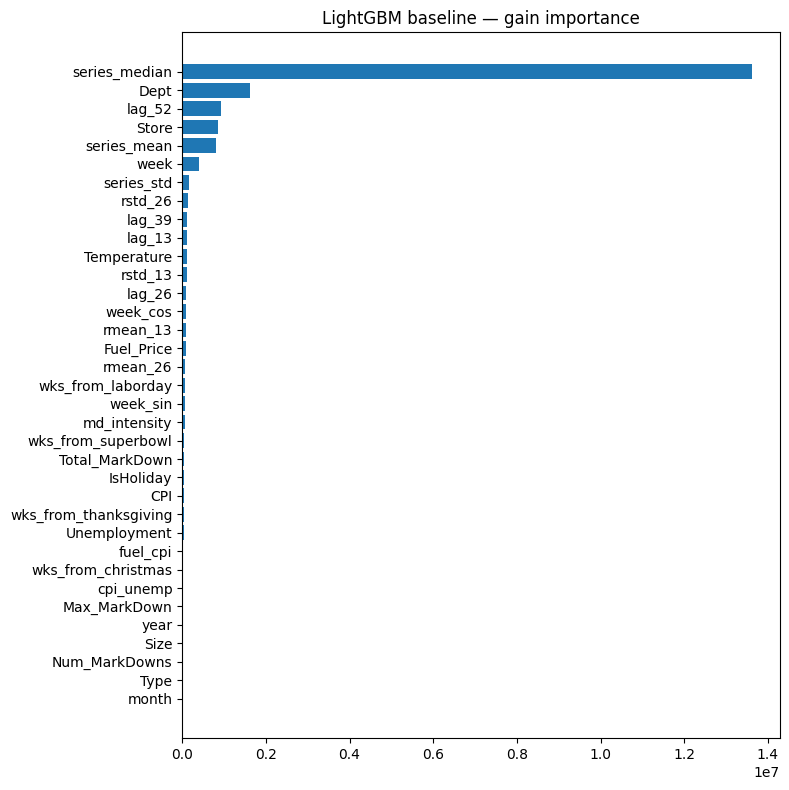

🏃 View run LightGBM_Baseline_Analysis at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/a7de3c89900f4080bd120310e9dcd5ff
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7
      feature         gain
series_median 1.360870e+07
         Dept 1.617810e+06
       lag_52 9.205777e+05
        Store 8.661241e+05
  series_mean 8.035867e+05
         week 4.111332e+05
   series_std 1.706177e+05
      rstd_26 1.306646e+05
       lag_39 1.249123e+05
       lag_13 1.233957e+05
  Temperature 1.070988e+05
      rstd_13 1.035798e+05


In [14]:
import matplotlib.pyplot as plt

imp = (pd.DataFrame({'feature': FEATURES,
                     'gain': model.booster_.feature_importance(importance_type='gain')})
       .sort_values('gain', ascending=False))

plt.figure(figsize=(8, 8))
plt.barh(imp['feature'][::-1], imp['gain'][::-1])
plt.title('LightGBM baseline — gain importance')
plt.tight_layout()
plt.savefig('feat_importance_baseline.png', dpi=120)
plt.show()

with mlflow.start_run(run_name='LightGBM_Baseline_Analysis'):
    mlflow.set_tags({'stage': 'analysis', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.log_artifact('feat_importance_baseline.png')
    mlflow.log_text(imp.to_string(index=False), 'feature_importance.txt')

print(imp.head(12).to_string(index=False))

## 10. Tuning

In [15]:
import itertools, time

grid = list(itertools.product([0.03, 0.05],        # learning_rate
                              [63, 127, 255],      # num_leaves
                              [20, 60]))           # min_child_samples
results = []

with mlflow.start_run(run_name='LightGBM_Tuning'):
    mlflow.set_tags({'stage': 'tuning', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        '12-config grid: lr x num_leaves x min_child_samples, subsample/colsample '
        'fixed 0.8. Selection on wmae_600 (comparable metric). Baseline: 3088.3.')

    for i, (lr, leaves, mcs) in enumerate(grid, 1):
        t0 = time.time()
        m = lgb.LGBMRegressor(objective='l1', n_estimators=4000, learning_rate=lr,
                              num_leaves=leaves, min_child_samples=mcs,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                              random_state=7, n_jobs=-1, verbosity=-1)
        m.fit(X_tr, y_tr, sample_weight=w_tr,
              eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
              eval_metric='l1',
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
        p = m.predict(X_val)
        m6 = val_df.assign(pred=p)[val_df['in600']]
        r = dict(lr=lr, num_leaves=leaves, min_child_samples=mcs,
                 wmae_600=wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1),
                 wmae_all=wmae(val_df['y_true'], p, val_df['IsHoliday'] == 1),
                 best_iter=m.best_iteration_, mins=round((time.time()-t0)/60, 1))
        results.append(r)
        print(f"[{i}/12] lr={lr} leaves={leaves} mcs={mcs} -> "
              f"wmae_600={r['wmae_600']:.1f} all={r['wmae_all']:.1f} it={r['best_iter']}")

    res = pd.DataFrame(results).sort_values('wmae_600')
    best = res.iloc[0]
    mlflow.log_text(res.to_string(index=False), 'tuning_results.txt')
    mlflow.log_params({'grid_size': len(grid), 'selection': 'wmae_600'})
    mlflow.log_metrics({'best_wmae_600': best['wmae_600'], 'best_wmae_all': best['wmae_all']})
    print('\nBest:', dict(best))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2190]	valid_0's l1: 1280.47
[1/12] lr=0.03 leaves=63 mcs=20 -> wmae_600=3006.5 all=1280.5 it=2190
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2300]	valid_0's l1: 1273.83
[2/12] lr=0.03 leaves=63 mcs=60 -> wmae_600=2992.6 all=1273.8 it=2300
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1235]	valid_0's l1: 1285.24
[3/12] lr=0.03 leaves=127 mcs=20 -> wmae_600=3029.9 all=1285.2 it=1235
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2052]	valid_0's l1: 1270.54
[4/12] lr=0.03 leaves=127 mcs=60 -> wmae_600=2999.4 all=1270.5 it=2052
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[415]	valid_0's l1: 1285.7
[5/12] lr=0.03 leaves=255 mcs=20 -> wmae_600=3037.7 all=1285.7 it=415
Training until valid

In [16]:
refine = [(0.02, 255, 60), (0.02, 255, 100), (0.02, 511, 60), (0.02, 511, 100)]
results2 = []

with mlflow.start_run(run_name='LightGBM_Tuning_Refine'):
    mlflow.set_tags({'stage': 'tuning', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Refinement past grid boundary: lr=0.02, leaves {255,511}, mcs {60,100}, '
        'ceiling 10000 iters. Best so far: 2971.7 (lr .03 / 255 / 60).')

    for i, (lr, leaves, mcs) in enumerate(refine, 1):
        m = lgb.LGBMRegressor(objective='l1', n_estimators=10000, learning_rate=lr,
                              num_leaves=leaves, min_child_samples=mcs,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                              random_state=7, n_jobs=-1, verbosity=-1)
        m.fit(X_tr, y_tr, sample_weight=w_tr,
              eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
              eval_metric='l1',
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
        p = m.predict(X_val)
        m6 = val_df.assign(pred=p)[val_df['in600']]
        r = dict(lr=lr, num_leaves=leaves, min_child_samples=mcs,
                 wmae_600=wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1),
                 wmae_all=wmae(val_df['y_true'], p, val_df['IsHoliday'] == 1),
                 best_iter=m.best_iteration_)
        results2.append(r)
        print(f"[{i}/4] lr={lr} leaves={leaves} mcs={mcs} -> "
              f"wmae_600={r['wmae_600']:.1f} all={r['wmae_all']:.1f} it={r['best_iter']}")

    res2 = pd.DataFrame(results2).sort_values('wmae_600')
    mlflow.log_text(res2.to_string(index=False), 'refine_results.txt')
    mlflow.log_metrics({'best_wmae_600': res2.iloc[0]['wmae_600'],
                        'best_wmae_all': res2.iloc[0]['wmae_all']})
    print('\nBest:', dict(res2.iloc[0]))

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[4643]	valid_0's l1: 1251.97
[1/4] lr=0.02 leaves=255 mcs=60 -> wmae_600=2970.9 all=1252.0 it=4643
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[5627]	valid_0's l1: 1224.36
[2/4] lr=0.02 leaves=255 mcs=100 -> wmae_600=2888.8 all=1224.4 it=5627
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[3710]	valid_0's l1: 1227.74
[3/4] lr=0.02 leaves=511 mcs=60 -> wmae_600=2875.4 all=1227.7 it=3710
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[3685]	valid_0's l1: 1223.77
[4/4] lr=0.02 leaves=511 mcs=100 -> wmae_600=2877.1 all=1223.8 it=3685

Best: {'lr': np.float64(0.02), 'num_leaves': np.float64(511.0), 'min_child_samples': np.float64(60.0), 'wmae_600': np.float64(2875.351181001732), 'wmae_all': np.float64(1227.7432154779794), 'best_iter': np.float64

## 11. log1p A/B

In [17]:
BEST = dict(objective='l1', n_estimators=10000, learning_rate=0.02,
            num_leaves=511, min_child_samples=60,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            random_state=7, n_jobs=-1, verbosity=-1)

# log1p needs non-negative input; shift by global min (few negative returns)
shift = max(0.0, -float(y_tr.min()))
y_tr_log = np.log1p(y_tr + shift)
y_val_log = np.log1p(y_val + shift)

with mlflow.start_run(run_name='LightGBM_log1p_AB'):
    mlflow.set_tags({'stage': 'ablation', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'A/B: log1p target vs raw, best config (lr.02/511/60). Raw baseline: '
        'wmae_600=2875.4. Predictions inverse-transformed before WMAE.')

    m = lgb.LGBMRegressor(**BEST)
    m.fit(X_tr, y_tr_log, sample_weight=w_tr,
          eval_set=[(X_val, y_val_log)], eval_sample_weight=[w_val],
          eval_metric='l1',
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])

    p = np.expm1(m.predict(X_val)) - shift
    m6 = val_df.assign(pred=p)[val_df['in600']]
    w6 = wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1)
    wa = wmae(val_df['y_true'], p, val_df['IsHoliday'] == 1)

    mlflow.log_params({**BEST, 'target': 'log1p', 'shift': shift})
    mlflow.log_metrics({'wmae_600': w6, 'wmae_all': wa, 'best_iteration': m.best_iteration_})
    print(f'log1p: wmae_600={w6:.1f} | wmae_all={wa:.1f} | it={m.best_iteration_} '
          f'(raw was 2875.4 / 1227.7)')

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[3517]	valid_0's l1: 0.0545386
log1p: wmae_600=2825.8 | wmae_all=1218.0 | it=3517 (raw was 2875.4 / 1227.7)
🏃 View run LightGBM_log1p_AB at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/bab502fd07cf455bbbc731baa324c0fc
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7


## 12. Feature v2 - svale-free lags

In [19]:
def add_ratio_features(df):
    df = df.copy()
    denom = df['series_median'].replace(0, np.nan)
    for k in LAGS:
        df[f'lag_{k}_ratio'] = df[f'lag_{k}'] / denom
    df['rmean_13_ratio'] = df['rmean_13'] / denom
    return df

# rmean_52: same shift-then-roll pattern as build_panel
s = panel.set_index(['Store', 'Dept', 'Date'])['Weekly_Sales']
base = s.groupby(level=['Store', 'Dept'], observed=True).shift(HORIZON)
extra = (base.groupby(level=['Store', 'Dept'], observed=True)
             .rolling(52, min_periods=13).mean()
             .droplevel([0, 1]).rename('rmean_52'))

for frame in ('train_df', 'val_df'):
    df = globals()[frame].merge(extra.reset_index(), on=['Store', 'Dept', 'Date'], how='left')
    globals()[frame] = add_ratio_features(df)

FEATURES_V2 = FEATURES + [f'lag_{k}_ratio' for k in LAGS] + ['rmean_13_ratio', 'rmean_52']

X_tr, X_val = train_df[FEATURES_V2], val_df[FEATURES_V2]
y_tr, y_val = train_df['Weekly_Sales'], val_df['y_true']
y_tr_log, y_val_log = np.log1p(y_tr + shift), np.log1p(y_val + shift)

with mlflow.start_run(run_name='LightGBM_FeaturesV2'):
    mlflow.set_tags({'stage': 'feature_engineering', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Adds scale-free lag ratios (lag_k/series_median), rmean_13_ratio, rmean_52. '
        'log1p target, best config. Bar to beat: 2825.8.')

    m = lgb.LGBMRegressor(**BEST)
    m.fit(X_tr, y_tr_log, sample_weight=w_tr,
          eval_set=[(X_val, y_val_log)], eval_sample_weight=[w_val],
          eval_metric='l1',
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])

    p = np.expm1(m.predict(X_val)) - shift
    m6 = val_df.assign(pred=p)[val_df['in600']]
    w6 = wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1)
    wa = wmae(val_df['y_true'], p, val_df['IsHoliday'] == 1)
    mlflow.log_params({**BEST, 'target': 'log1p', 'n_features': len(FEATURES_V2)})
    mlflow.log_metrics({'wmae_600': w6, 'wmae_all': wa, 'best_iteration': m.best_iteration_})
    print(f'v2: wmae_600={w6:.1f} | wmae_all={wa:.1f} | it={m.best_iteration_} (bar: 2825.8)')

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[5012]	valid_0's l1: 0.0546293
v2: wmae_600=2768.4 | wmae_all=1205.8 | it=5012 (bar: 2825.8)
🏃 View run LightGBM_FeaturesV2 at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/518d75be3f404120af3446bcde60c979
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7


## 13. Feature v3 - smoothed year-ago + cross-series level

In [20]:
# lag_52_smooth: mean of lags 51..53 (all >= HORIZON, leak-free)
for k in [51, 53]:
    col = s.groupby(level=['Store', 'Dept'], observed=True).shift(k).rename(f'lag_{k}')
    for frame in ('train_df', 'val_df'):
        globals()[frame] = globals()[frame].merge(
            col.reset_index(), on=['Store', 'Dept', 'Date'], how='left')

for frame in ('train_df', 'val_df'):
    df = globals()[frame]
    df['lag_52_smooth'] = df[['lag_51', 'lag_52', 'lag_53']].mean(axis=1)
    df['lag_52_smooth_ratio'] = df['lag_52_smooth'] / df['series_median'].replace(0, np.nan)

# dept/store medians from pre-cutoff observed data only
obs = train[train['Date'] < val_start]
dept_med = obs.groupby('Dept')['Weekly_Sales'].median().rename('dept_median')
store_med = obs.groupby('Store')['Weekly_Sales'].median().rename('store_median')
for frame in ('train_df', 'val_df'):
    df = globals()[frame]
    df['Dept_i'] = df['Dept'].astype(int); df['Store_i'] = df['Store'].astype(int)
    df = (df.merge(dept_med, left_on='Dept_i', right_index=True, how='left')
            .merge(store_med, left_on='Store_i', right_index=True, how='left')
            .drop(columns=['Dept_i', 'Store_i']))
    globals()[frame] = df

FEATURES_V3 = FEATURES_V2 + ['lag_52_smooth', 'lag_52_smooth_ratio', 'dept_median', 'store_median']

X_tr, X_val = train_df[FEATURES_V3], val_df[FEATURES_V3]

with mlflow.start_run(run_name='LightGBM_FeaturesV3'):
    mlflow.set_tags({'stage': 'feature_engineering', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Adds lag_52_smooth (mean lags 51-53) + ratio, dept_median, store_median '
        '(pre-cutoff only). Bar: 2768.4. Prophet best: 2755.1.')

    m = lgb.LGBMRegressor(**BEST)
    m.fit(X_tr, y_tr_log, sample_weight=w_tr,
          eval_set=[(X_val, y_val_log)], eval_sample_weight=[w_val],
          eval_metric='l1',
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])

    p = np.expm1(m.predict(X_val)) - shift
    m6 = val_df.assign(pred=p)[val_df['in600']]
    w6 = wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1)
    wa = wmae(val_df['y_true'], p, val_df['IsHoliday'] == 1)
    mlflow.log_params({**BEST, 'target': 'log1p', 'n_features': len(FEATURES_V3)})
    mlflow.log_metrics({'wmae_600': w6, 'wmae_all': wa, 'best_iteration': m.best_iteration_})
    print(f'v3: wmae_600={w6:.1f} | wmae_all={wa:.1f} | it={m.best_iteration_} (bar: 2768.4)')

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[2854]	valid_0's l1: 0.0537305
v3: wmae_600=2766.0 | wmae_all=1193.6 | it=2854 (bar: 2768.4)
🏃 View run LightGBM_FeaturesV3 at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/c7a56bf85b294b1a8bd46030e222967f
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7


## 14. Seed Ensemble

In [21]:
SEEDS = [7, 77, 777]
N_EST = 2900  # ~v3's best_iter

preds_log = []
with mlflow.start_run(run_name='LightGBM_SeedEnsemble'):
    mlflow.set_tags({'stage': 'ensemble', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        '3-seed average of v3 config (fixed 2900 iters, no per-seed early stop). '
        'Bar: single-seed v3 2766.0; Prophet best 2755.1.')

    for sd in SEEDS:
        cfg = {**BEST, 'random_state': sd, 'n_estimators': N_EST}
        m = lgb.LGBMRegressor(**cfg)
        m.fit(X_tr, y_tr_log, sample_weight=w_tr)
        preds_log.append(m.predict(X_val))
        p_i = np.expm1(preds_log[-1]) - shift
        m6 = val_df.assign(pred=p_i)[val_df['in600']]
        print(f'seed {sd}: wmae_600={wmae(m6["y_true"], m6["pred"], m6["IsHoliday"]==1):.1f}')

    p = np.expm1(np.mean(preds_log, axis=0)) - shift
    m6 = val_df.assign(pred=p)[val_df['in600']]
    w6 = wmae(m6['y_true'], m6['pred'], m6['IsHoliday'] == 1)
    wa = wmae(val_df['y_true'], p, val_df['IsHoliday'] == 1)
    mlflow.log_params({**BEST, 'seeds': str(SEEDS), 'n_estimators_fixed': N_EST,
                       'target': 'log1p', 'n_features': len(FEATURES_V3)})
    mlflow.log_metrics({'wmae_600': w6, 'wmae_all': wa})
    print(f'\nensemble: wmae_600={w6:.1f} | wmae_all={wa:.1f} (single: 2766.0)')

seed 7: wmae_600=2765.9
seed 77: wmae_600=2769.2
seed 777: wmae_600=2784.6

ensemble: wmae_600=2757.2 | wmae_all=1189.6 (single: 2766.0)
🏃 View run LightGBM_SeedEnsemble at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/59854e981b9d49dbb884613a3286b3f9
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7


## 15. Final Pipeline

In [22]:
def featurize(train_raw, target_raw, stores_raw, feats_raw):
    """Raw csv frames in -> feature matrix for target rows out (v3 feature set)."""
    f = feats_raw.copy()
    md_ = [f'MarkDown{i}' for i in range(1, 6)]
    f[md_] = f[md_].fillna(0.0)
    f['Total_MarkDown'] = f[md_].sum(axis=1)
    f['Num_MarkDowns'] = (f[md_] > 0).sum(axis=1)
    f['Max_MarkDown'] = f[md_].max(axis=1)
    f = f.sort_values(['Store', 'Date'])
    f[['CPI', 'Unemployment']] = f.groupby('Store')[['CPI', 'Unemployment']].ffill()
    ex = f.drop(columns=['IsHoliday'] + md_)

    global exog, stores
    _exog_bak, _stores_bak = exog, stores
    exog, stores = ex, stores_raw.copy()
    try:
        pan = build_panel(train_raw, target_raw)
    finally:
        exog, stores = _exog_bak, _stores_bak

    out = pan[pan['is_target']].copy()
    hist_part = pan[~pan['is_target']]

    # v2: ratios + rmean_52
    sv = pan.set_index(['Store', 'Dept', 'Date'])['Weekly_Sales']
    base = sv.groupby(level=['Store', 'Dept'], observed=True).shift(HORIZON)
    r52 = (base.groupby(level=['Store', 'Dept'], observed=True)
               .rolling(52, min_periods=13).mean().droplevel([0, 1]).rename('rmean_52'))
    out = out.merge(r52.reset_index(), on=['Store', 'Dept', 'Date'], how='left')
    denom = out['series_median'].replace(0, np.nan)
    for k in LAGS:
        out[f'lag_{k}_ratio'] = out[f'lag_{k}'] / denom
    out['rmean_13_ratio'] = out['rmean_13'] / denom

    # v3: smoothed year-ago + dept/store medians (history only)
    for k in [51, 53]:
        col = sv.groupby(level=['Store', 'Dept'], observed=True).shift(k).rename(f'lag_{k}')
        out = out.merge(col.reset_index(), on=['Store', 'Dept', 'Date'], how='left')
    out['lag_52_smooth'] = out[['lag_51', 'lag_52', 'lag_53']].mean(axis=1)
    out['lag_52_smooth_ratio'] = out['lag_52_smooth'] / denom
    out = (out.assign(Dept_i=out['Dept'].astype(int), Store_i=out['Store'].astype(int))
              .merge(train_raw.groupby('Dept')['Weekly_Sales'].median().rename('dept_median'),
                     left_on='Dept_i', right_index=True, how='left')
              .merge(train_raw.groupby('Store')['Weekly_Sales'].median().rename('store_median'),
                     left_on='Store_i', right_index=True, how='left')
              .drop(columns=['Dept_i', 'Store_i']))
    return out, hist_part

# --- refit on FULL train, 3 seeds ---
# training matrix: featurize with target=None trick — reuse existing per-row logic
full_panel_out, full_hist = featurize(train, None, stores,
                                      pd.read_csv('walmart_data/features.csv', parse_dates=['Date']))
# target=None -> out is empty; training rows come from hist_part
tr_full = full_hist[full_hist['was_observed']].copy()
# rebuild v2/v3 features for training rows the same way
sv = full_hist.set_index(['Store', 'Dept', 'Date'])['Weekly_Sales']
base = sv.groupby(level=['Store', 'Dept'], observed=True).shift(HORIZON)
r52 = (base.groupby(level=['Store', 'Dept'], observed=True)
           .rolling(52, min_periods=13).mean().droplevel([0, 1]).rename('rmean_52'))
tr_full = tr_full.merge(r52.reset_index(), on=['Store', 'Dept', 'Date'], how='left')
den = tr_full['series_median'].replace(0, np.nan)
for k in LAGS:
    tr_full[f'lag_{k}_ratio'] = tr_full[f'lag_{k}'] / den
tr_full['rmean_13_ratio'] = tr_full['rmean_13'] / den
for k in [51, 53]:
    col = sv.groupby(level=['Store', 'Dept'], observed=True).shift(k).rename(f'lag_{k}')
    tr_full = tr_full.merge(col.reset_index(), on=['Store', 'Dept', 'Date'], how='left')
tr_full['lag_52_smooth'] = tr_full[['lag_51', 'lag_52', 'lag_53']].mean(axis=1)
tr_full['lag_52_smooth_ratio'] = tr_full['lag_52_smooth'] / den
tr_full = (tr_full.assign(Dept_i=tr_full['Dept'].astype(int), Store_i=tr_full['Store'].astype(int))
           .merge(train.groupby('Dept')['Weekly_Sales'].median().rename('dept_median'),
                  left_on='Dept_i', right_index=True, how='left')
           .merge(train.groupby('Store')['Weekly_Sales'].median().rename('store_median'),
                  left_on='Store_i', right_index=True, how='left')
           .drop(columns=['Dept_i', 'Store_i']))

CATS = {c: tr_full[c].astype('category').cat.categories for c in ['Store', 'Dept', 'Type']}
for c, cats in CATS.items():
    tr_full[c] = pd.Categorical(tr_full[c], categories=cats)

Xf = tr_full[FEATURES_V3]
yf_log = np.log1p(tr_full['Weekly_Sales'] + shift)
wf = np.where(tr_full['IsHoliday'] == 1, 5.0, 1.0)

final_models = []
for sd in SEEDS:
    m = lgb.LGBMRegressor(**{**BEST, 'random_state': sd, 'n_estimators': N_EST})
    m.fit(Xf, yf_log, sample_weight=wf)
    final_models.append(m)
print('refit done:', len(final_models), 'models on', Xf.shape)

/tmp/ipykernel_2722/1794197277.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_target'] = df['is_target'].astype(object).fillna(False).astype(bool)


refit done: 3 models on (421570, 45)


In [23]:
import mlflow.pyfunc
from mlflow.models import infer_signature

class LGBMEnsemblePipeline(mlflow.pyfunc.PythonModel):
    def __init__(self, models, feature_list, cats, shift):
        self.models = models
        self.feature_list = feature_list
        self.cats = cats
        self.shift = shift

    def load_context(self, context):
        self.train_df = pd.read_csv(context.artifacts['train_csv'], parse_dates=['Date'])
        self.stores_df = pd.read_csv(context.artifacts['stores_csv'])
        self.feats_df = pd.read_csv(context.artifacts['features_csv'], parse_dates=['Date'])

    def predict(self, context, model_input):
        ti = model_input.copy().reset_index(drop=True)          # mlflow 3.x gotcha
        ti['Date'] = pd.to_datetime(ti['Date'])
        tgt = ti[['Store', 'Dept', 'Date']].drop_duplicates()
        out, _ = featurize(self.train_df, tgt, self.stores_df, self.feats_df)
        for c, cats in self.cats.items():
            out[c] = pd.Categorical(out[c], categories=cats)
        X = out[self.feature_list]
        pred_log = np.mean([m.predict(X) for m in self.models], axis=0)
        out = out.assign(pred=np.expm1(pred_log) - self.shift)
        res = ti.merge(out[['Store', 'Dept', 'Date', 'pred']],
                       on=['Store', 'Dept', 'Date'], how='left')
        return res['pred'].rename('Weekly_Sales')

pipeline = LGBMEnsemblePipeline(final_models, FEATURES_V3, CATS, shift)

sample_in = test.head(50)
artifacts = {'train_csv': 'walmart_data/train.csv',
             'stores_csv': 'walmart_data/stores.csv',
             'features_csv': 'walmart_data/features.csv'}

with mlflow.start_run(run_name='LightGBM_Final_Pipeline') as run:
    mlflow.set_tags({'stage': 'pipeline', 'model_family': 'LightGBM', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Final deliverable: 3-seed LightGBM ensemble (v3 features, log1p target, '
        'lr.02/511 leaves/mcs60, 2900 iters), refit on full train.csv. predict() '
        'takes raw test.csv, rebuilds features internally from shipped csvs. '
        'Val (pre-refit): wmae_600=2757.2, wmae_all=1189.6. Prophet best: 2755.1.')
    mlflow.log_params({**BEST, 'seeds': str(SEEDS), 'n_estimators_fixed': N_EST,
                       'target': 'log1p', 'shift': shift,
                       'n_features': len(FEATURES_V3), 'refit': 'full_train'})
    mlflow.log_metrics({'wmae_600': 2757.2, 'wmae_all': 1189.6})

    model_info = mlflow.pyfunc.log_model(
        name='lightgbm_pipeline',
        python_model=pipeline,
        artifacts=artifacts,
        signature=infer_signature(sample_in,
                                  pd.Series(np.zeros(len(sample_in)), name='Weekly_Sales')),
        pip_requirements=['lightgbm', 'pandas', 'numpy', 'scikit-learn'])

print('logged:', model_info.model_uri)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/doc

🏃 View run LightGBM_Final_Pipeline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7/runs/567d6e5a8176494e8c28c6e64cad604d
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/7
logged: models:/m-73236e34515444b39e1a2a651b6095dd


## 16. Verification - load round-trip + smoke test

In [24]:
loaded = mlflow.pyfunc.load_model(model_info.model_uri)

preds = loaded.predict(test)                 # full raw test.csv, ~115k rows
smoke = test.copy()
smoke['pred'] = preds.values

print('rows:', len(smoke), '| NaN preds:', smoke['pred'].isna().sum())
print('median:', round(smoke['pred'].median(), 1),
      '| p1:', round(smoke['pred'].quantile(0.01), 1),
      '| p99:', round(smoke['pred'].quantile(0.99), 1))

wk = smoke.groupby('Date')['pred'].sum()
print('\nweekly totals around Thanksgiving/Christmas:')
print((wk['2012-11-09':'2012-12-28'] / 1e6).round(1))

s2092 = smoke[(smoke['Store'] == 20) & (smoke['Dept'] == 92)]
print('\nStore 20 / Dept 92 (big series) first 5:')
print(s2092[['Date', 'pred']].head().to_string(index=False))

/tmp/ipykernel_2722/1794197277.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_target'] = df['is_target'].astype(object).fillna(False).astype(bool)


rows: 115064 | NaN preds: 0
median: 7663.9 | p1: 9.6 | p99: 106533.6

weekly totals around Thanksgiving/Christmas:
Date
2012-11-09    48.7
2012-11-16    47.2
2012-11-23    65.8
2012-11-30    49.1
2012-12-07    54.7
2012-12-14    58.8
2012-12-21    73.7
2012-12-28    48.1
Name: pred, dtype: float64

Store 20 / Dept 92 (big series) first 5:
      Date          pred
2012-11-02 189636.723878
2012-11-09 205973.173117
2012-11-16 201477.912820
2012-11-23 204563.040409
2012-11-30 178163.402978
